# Import librabries

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_final.csv'
)

In [4]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,1.0,1,19,12.0,7,16,30,51,3,0
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,0.0,0,18,11.0,17,27,9,66,3,0
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,1.0,0,26,16.0,12,31,29,65,4,1
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,0.0,0,25,13.0,7,24,18,54,4,0


# Filter the Group Stage

In [6]:
group_stage = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Group'
]

In [7]:
group_stage

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3893832,2023-08-02,Jamaica Women's,Brazil Women's,Group,0,0,D,1,29.464669,...,0.0,0,22,12.0,13,30,46,67,8,1
92,3893833,2023-08-03,Germany Women's,Korea Republic Women's,Group,1,1,D,1,60.364924,...,0.0,0,16,10.0,14,14,32,64,1,0
93,3893833,2023-08-03,Korea Republic Women's,Germany Women's,Group,1,1,D,1,39.635076,...,0.0,0,25,12.0,10,28,26,64,2,0
94,3893834,2023-08-03,Colombia Women's,Morocco Women's,Group,0,1,L,0,58.744898,...,0.0,0,28,13.0,22,28,18,81,5,0


In [8]:
teams = womens_world_cup_stats["team"].unique()

list(teams)

["New Zealand Women's",
 "Norway Women's",
 "Australia Women's",
 "Republic of Ireland Women's",
 "Philippines Women's",
 "Switzerland Women's",
 "Canada Women's",
 "Nigeria Women's",
 "Costa Rica Women's",
 "Spain Women's",
 "United States Women's",
 "Vietnam Women's",
 "Japan Women's",
 'Zambia W',
 "England Women's",
 "Haiti Women's",
 "China PR Women's",
 "Denmark Women's",
 "South Africa Women's",
 "Sweden Women's",
 "Netherlands Women's",
 "Portugal Women's",
 "France Women's",
 "Jamaica Women's",
 "Germany Women's",
 "Morocco Women's",
 "Argentina Women's",
 "Italy Women's",
 "Brazil Women's",
 "Panama Women's",
 "Colombia Women's",
 "Korea Republic Women's"]

# Analysis New Zealand's Group Stage games

In [10]:
team = "New Zealand Women's"

games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == team) |
    (womens_world_cup_stats["opponent"] == team)
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
0,3893787,New Zealand Women's,Norway Women's,Group
1,3893787,Norway Women's,New Zealand Women's,Group
32,3893803,New Zealand Women's,Philippines Women's,Group
33,3893803,Philippines Women's,New Zealand Women's,Group
60,3893817,New Zealand Women's,Switzerland Women's,Group
61,3893817,Switzerland Women's,New Zealand Women's,Group


In [11]:
womens_world_cup_stats.columns

Index(['match_id', 'match_date', 'team', 'opponent', 'stage', 'goals_for',
       'goals_against', 'result', 'points', 'possession_pct', 'passes',
       'pass_accuracy_pct', 'shots', 'shots_on_target', 'shot_accuracy_pct',
       'xG', 'xG_per_shot', 'goals_minus_xG', 'conversion_pct', 'big_chances',
       'key_passes', 'corners', 'crosses', 'progressive_passes',
       'progressive_carries', 'final_third_entries', 'box_entries',
       'high_turnovers', 'shots_after_turnover', 'goals_after_turnover',
       'set_piece_goals', 'tackles', 'tackles_won', 'interceptions', 'blocks',
       'clearances', 'recoveries', 'saves', 'clean_sheet'],
      dtype='object')

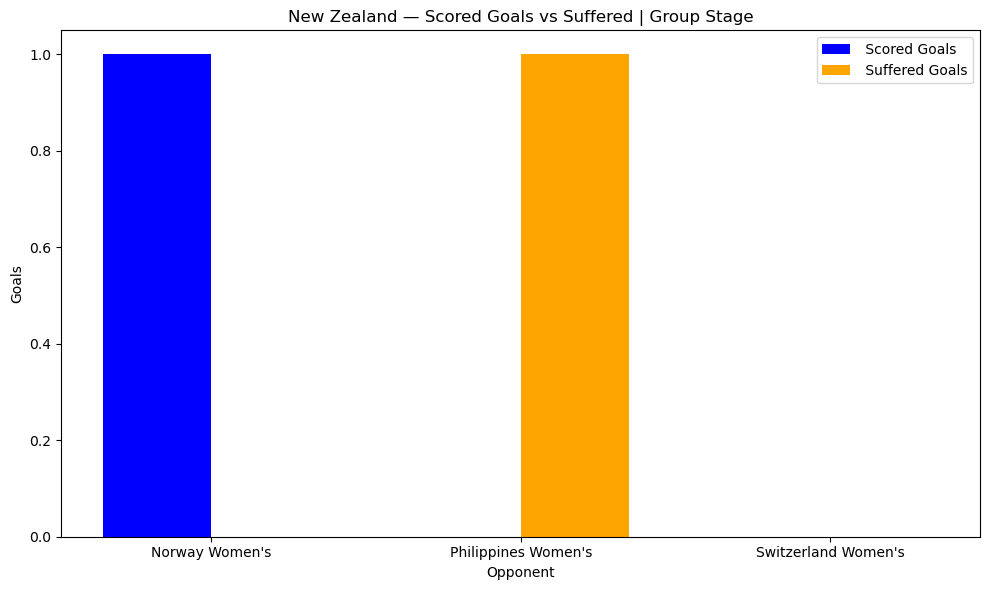

In [12]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "New Zealand Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Suffered Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("New Zealand — Scored Goals vs Suffered | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

New Zealand played three games in the Group Stage of the World Cup. In these, they suffered a Goal from the Philippines and scored a Goal to Nowrway. Switzerland did not score any goal or suffer any, meaning they tied the game.

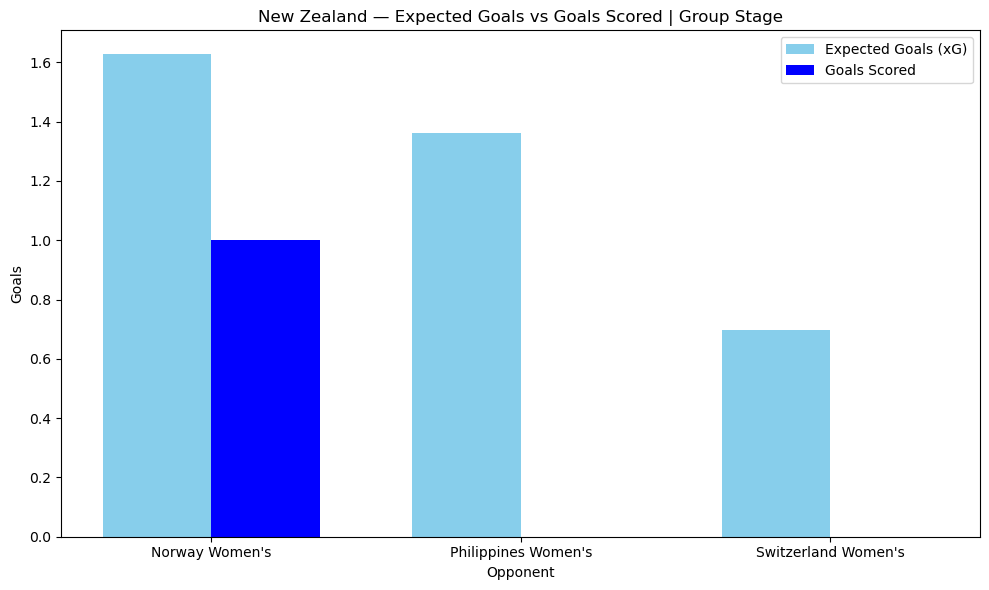

In [14]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "New Zealand Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("New Zealand — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

In Expected Goals, the metrics remained consistent; however, the team did not match the numbers. 

Game 1: NOR-NZ

- xG = 1.7: 2 goals (approx.)
- Result: scored 1 goal.

Game 2: PHIL-NZ

- xG = 1.4: 1 goals (approx.)
- Result: scored O goals.

Game 3: SWI-NZ

- xG = 0.6: 1 goals (approx.)
- Result: scored O goals.

This may explain the lack of consistency or even efficiency. 

# Analysis of NOR-NZ

In [17]:
# Select the New Zealand vs Norway match

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "New Zealand": [
        match.loc[
            match["team"] == "New Zealand Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Norway": [
        match.loc[
            match["team"] == "Norway Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["New Zealand", "Norway"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["New Zealand", "Norway"]
].round(1)


# Display table

comparison

,Metric,New Zealand,Norway
0,Goals,1.0,0.0
1,xG,1.6,1.0
2,Goals Minus xG,-0.6,-1.0
3,Shots,12.0,13.0
4,Shots on Target,2.0,1.0
5,Saves,2.0,1.0
6,Possession %,57.8,42.2
7,Pass Accuracy %,66.2,64.7
8,Progressive Passes,104.0,89.0
9,Progressive Carries,24.0,12.0


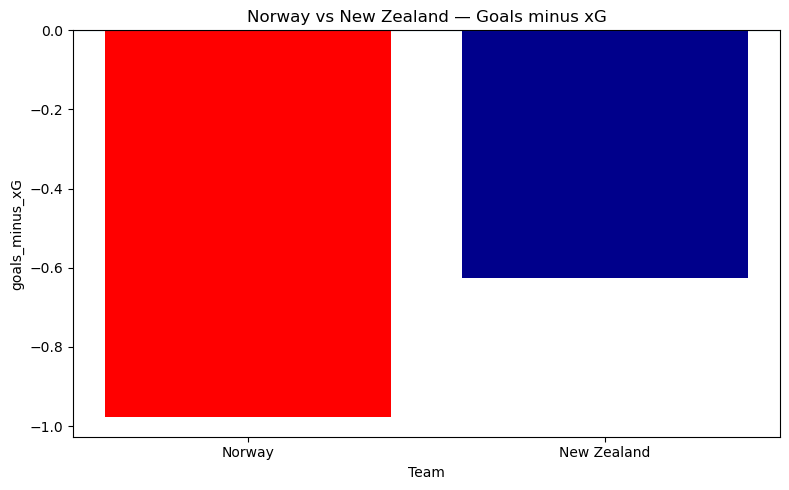

In [18]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
].copy()


teams = ["Norway", "New Zealand"]

goals_minus_xG = [
    match.loc[match["team"] == "Norway Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "New Zealand Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["red", "darkblue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Norway vs New Zealand — Goals minus xG")

plt.tight_layout()
plt.show()

- +1.0 ---------------  Scored 1 goal more than expected
- +0.5 ---------------  Scored 0.5 more than expected
-   0  ---------------- Scored exactly as expected
- -0.5 ---------------  Scored 0.5 fewer than expected
- -1.0 ---------------  Scored 1 fewer than expected

Both of the teams were bellow the xG, ensuring the lack of finalization during the game. But, let's see more!

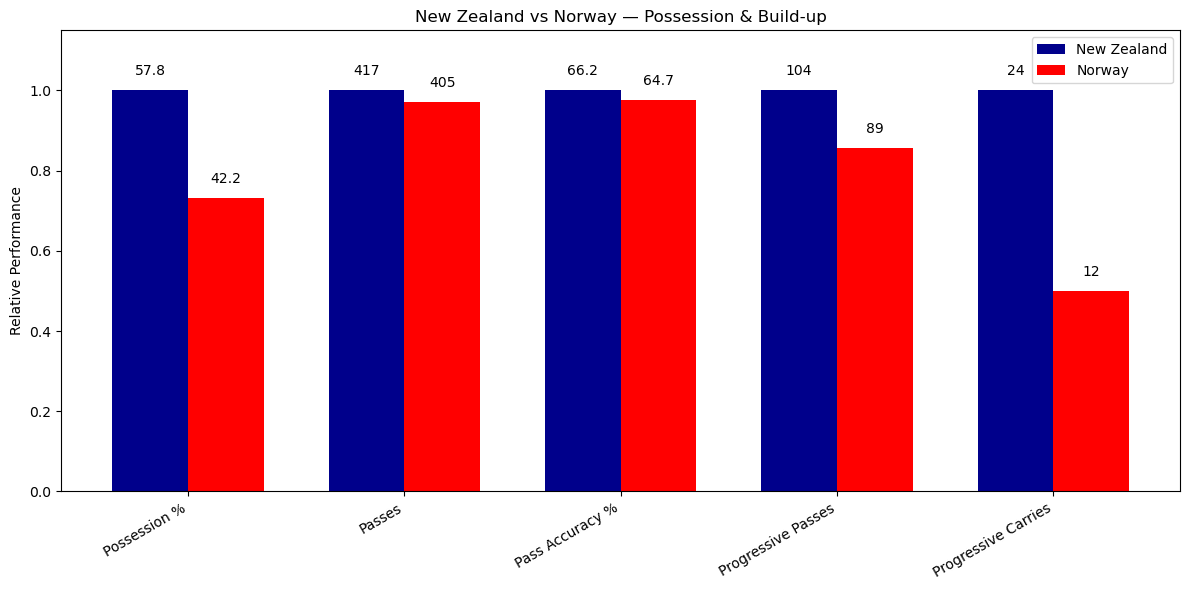

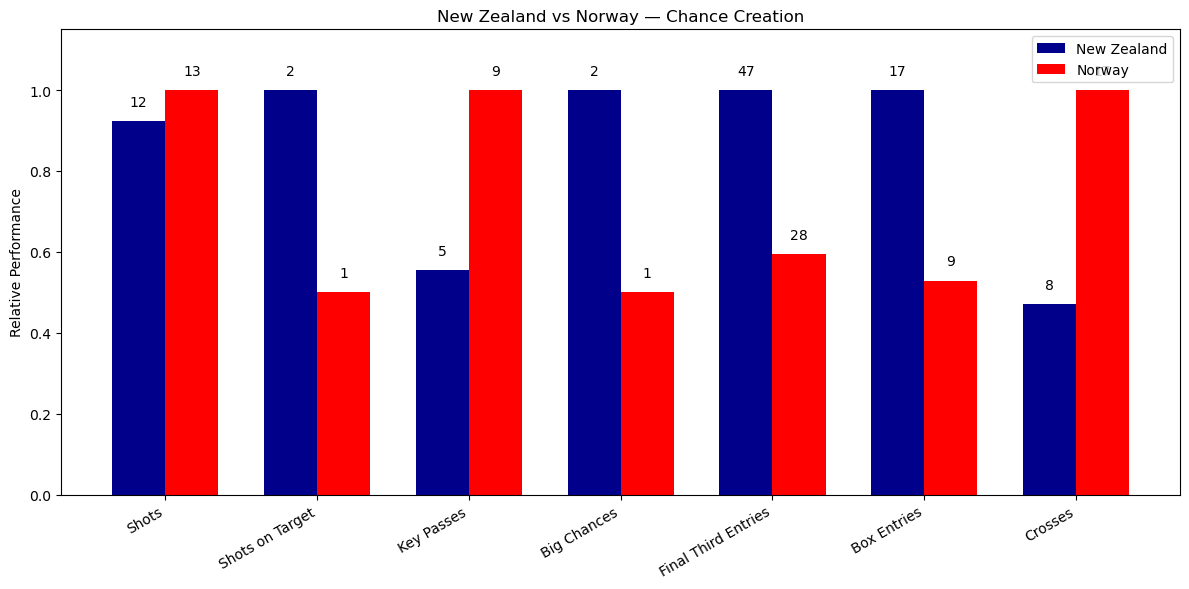

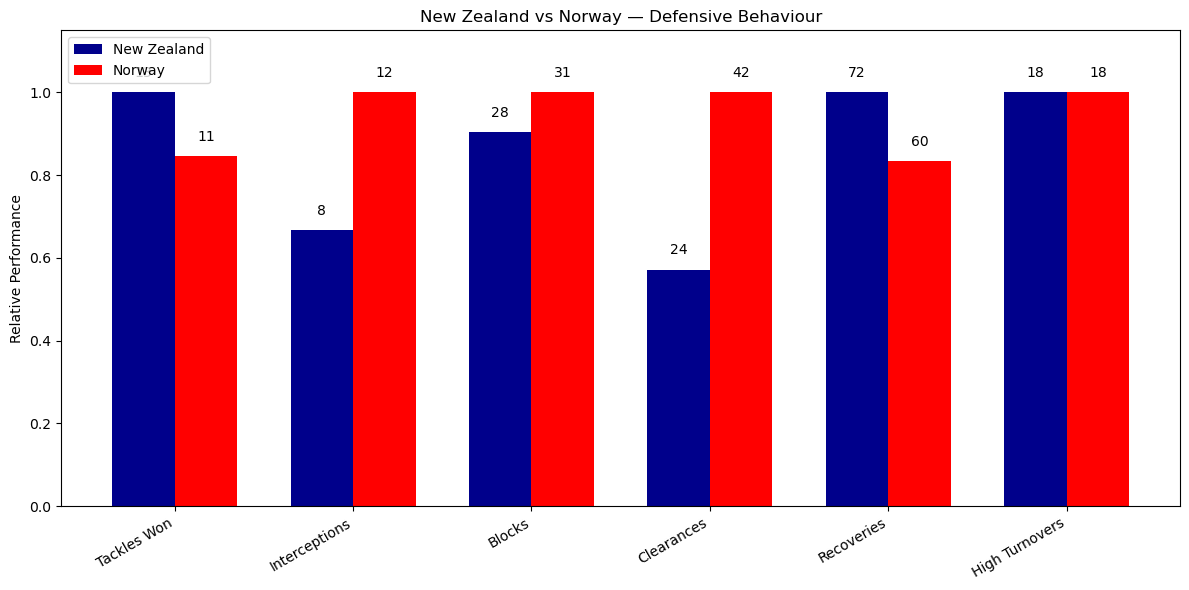

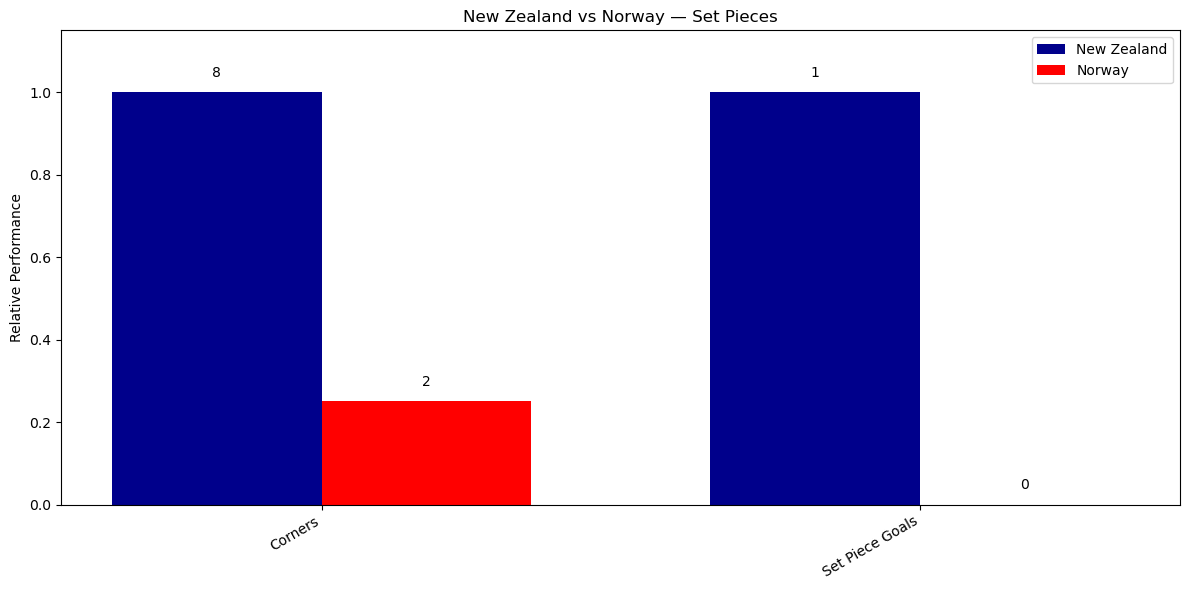

In [21]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
    |
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    )
]

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "New Zealand": "New Zealand Women's",
    "Norway": "Norway Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    nz_values = np.array([
        match.loc[
            match["team"] == team_names["New Zealand"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    norway_values = np.array([
        match.loc[
            match["team"] == team_names["Norway"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(nz_values, norway_values)

    # Normalize
    nz_normalized = np.divide(
        nz_values,
        max_values,
        out=np.zeros_like(nz_values),
        where=max_values != 0
    )

    norway_normalized = np.divide(
        norway_values,
        max_values,
        out=np.zeros_like(norway_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_nz = plt.bar(
        x - width / 2,
        nz_normalized,
        width,
        label="New Zealand",
        color="darkblue"
    )

    bars_norway = plt.bar(
        x + width / 2,
        norway_normalized,
        width,
        label="Norway",
        color="red"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_nz, nz_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_norway, norway_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"New Zealand vs Norway — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In this game, both teams put on very similar performances. However, New Zealand played a very offensive game, while Norway took a more defensive approach. Let’s take a look at the charts: <br>
<br>

*Possession and Build-up:* <br>
<br>
New Zealand clearly dominated Norway throughout the game, particularly in the following metrics:
“Possession %”: 57.8% - 42.2%
“Progressive passes”: 104 - 89
“Progressive carries”: 24 - 12
<br>

*Chance Creation* <br>
<br>
However, this graphic indicates that Norway, although more defensive, still created fairly good chances:
- "Shots": 12- 13
- "Key Passes": 5 - 9
<br>

*Defensive Behaviour* <br>
<br>
This is the chart that shows how Norway played, and also how New Zealand scored their goal. The bar shows a clear defensive approach; let's look at the metrics:
- "Interceptions": 8-12
- "Blocks": 31-28
- "Clearances": 42-24
<br>

*Set Pieces* <br>
<br>
Now, the last graphic shows that even though both teams had different approaches, they also had a similar performance. 
- "Corners": 8-2
- "Crosses": 8-17
- "Set Piece Goals": 0-0

## Correction of an error in the dataset

In [24]:
match[[
    "team",
    "opponent",
    "goals_for",
    "set_piece_goals"
]]

,team,opponent,goals_for,set_piece_goals
0,New Zealand Women's,Norway Women's,1,1
1,Norway Women's,New Zealand Women's,0,0


In [25]:
womens_world_cup_stats.loc[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ),
    "set_piece_goals"
] = 0

In [26]:
womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    )
][
    ["team", "opponent", "goals_for", "set_piece_goals"]
]

,team,opponent,goals_for,set_piece_goals
0,New Zealand Women's,Norway Women's,1,0


## Conclusion of NZ-NOR Match

New Zealand's goal was scored by Hannah Wilkinson in the 48th minute, following a build-up from the back: the team strung together a sequence of five passes, with Jacqui Hand delivering a cross to Wilkinson, who finished with a first-time shot.

Both teams were quite close in terms of performance, but the metrics and success were clearly in New Zealand's Women's National Team's favour.

# Analysis of PHI-NZ

In [30]:
# Select the New Zealand vs Philippines match

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "New Zealand": [
        match.loc[
            match["team"] == "New Zealand Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Philippines": [
        match.loc[
            match["team"] == "Philippines Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["New Zealand", "Philippines"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["New Zealand", "Philippines"]
].round(1)


# Display table

comparison

,Metric,New Zealand,Philippines
0,Goals,0.0,1.0
1,xG,1.4,0.3
2,Goals Minus xG,-1.4,0.7
3,Shots,18.0,4.0
4,Shots on Target,4.0,1.0
5,Saves,0.0,4.0
6,Possession %,70.5,29.5
7,Pass Accuracy %,71.4,47.9
8,Progressive Passes,154.0,88.0
9,Progressive Carries,25.0,4.0


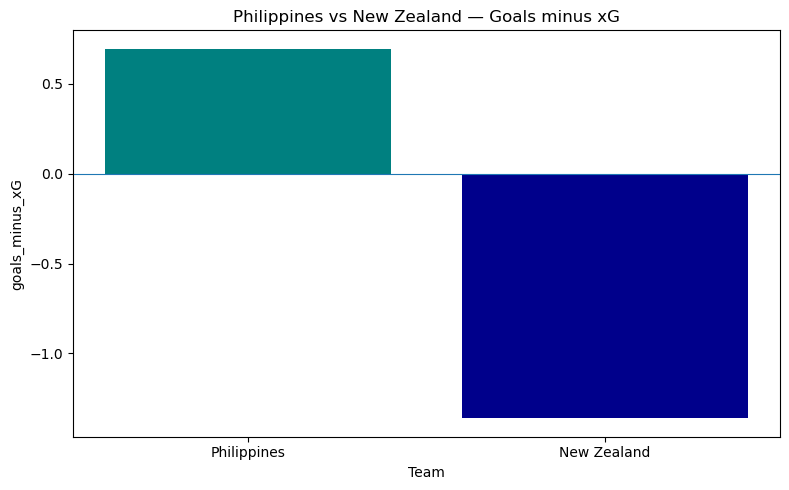

In [31]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
].copy()


teams = ["Philippines", "New Zealand"]

goals_minus_xG = [
    match.loc[match["team"] == "Philippines Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "New Zealand Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["teal", "darkblue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Philippines vs New Zealand — Goals minus xG")

plt.tight_layout()
plt.show()

This match was very uncommon and had an unusual outcome. Phillipines scored more than expected which was great for the National Team. However, New Zealand was far bellow of what was expected. 
What exacly happened? Let's look at the charts. 

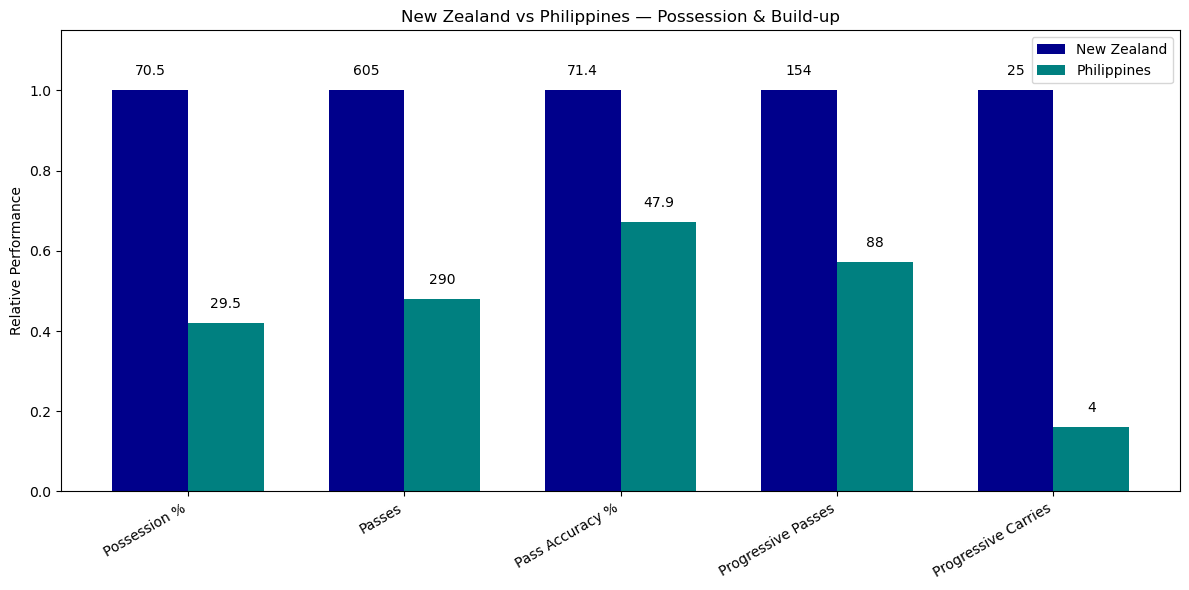

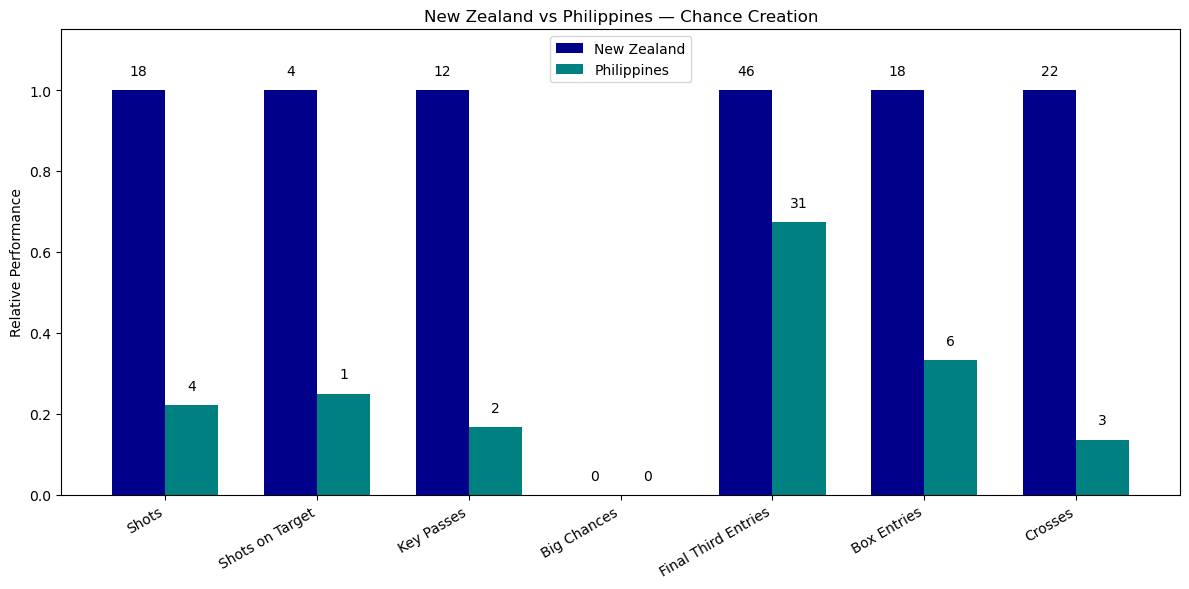

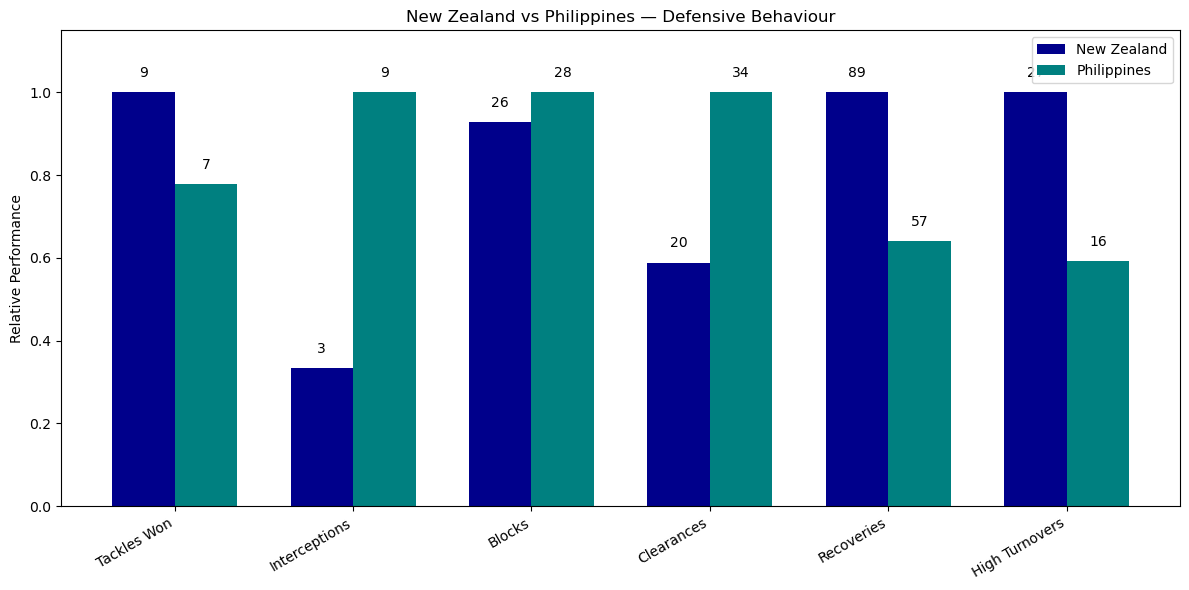

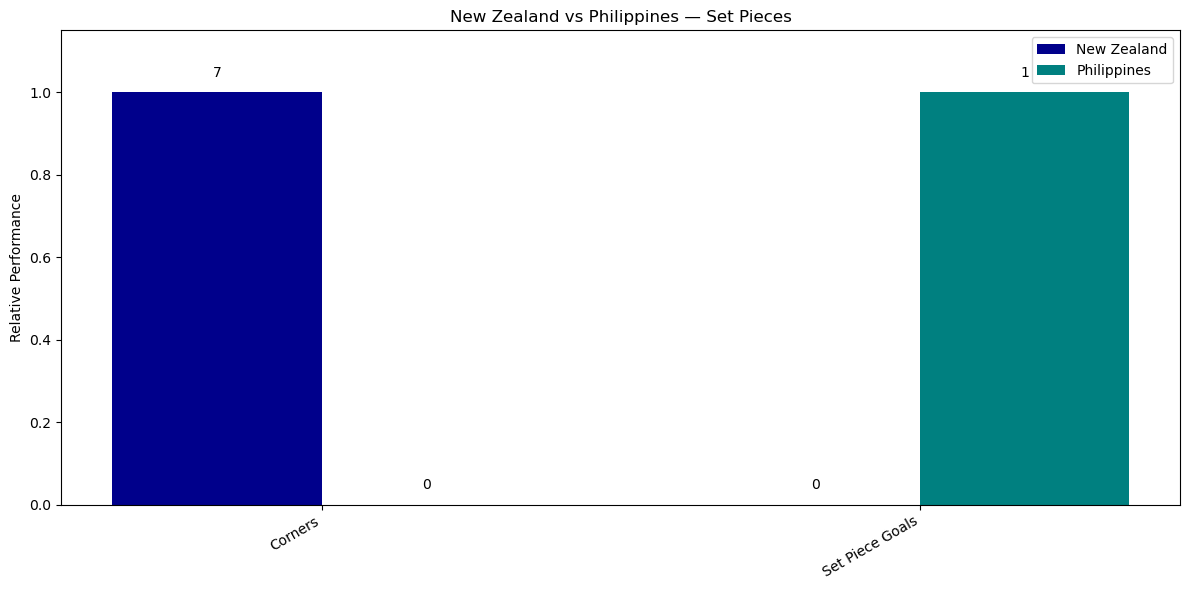

In [33]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
    |
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    )
]
# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses",
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "New Zealand": "New Zealand Women's",
    "Philippines": "Philippines Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    nz_values = np.array([
        match.loc[
            match["team"] == team_names["New Zealand"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    philippines_values = np.array([
        match.loc[
            match["team"] == team_names["Philippines"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(nz_values, philippines_values)

    # Normalize
    nz_normalized = np.divide(
        nz_values,
        max_values,
        out=np.zeros_like(nz_values),
        where=max_values != 0
    )

    philippines_normalized = np.divide(
        philippines_values,
        max_values,
        out=np.zeros_like(philippines_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_nz = plt.bar(
        x - width / 2,
        nz_normalized,
        width,
        label="New Zealand",
        color="darkblue"
    )

    bars_philippines = plt.bar(
        x + width / 2,
        philippines_normalized,
        width,
        label="Philippines",
        color="teal"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_nz, nz_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_philippines, philippines_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"New Zealand vs Philippines — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Correction of an error in the dataset

In [35]:
match[[
    "team",
    "opponent",
    "goals_for",
    "set_piece_goals"
]]

,team,opponent,goals_for,set_piece_goals
32,New Zealand Women's,Philippines Women's,0,0
33,Philippines Women's,New Zealand Women's,1,1


In [36]:
womens_world_cup_stats.loc[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    ),
    "set_piece_goals"
] = 0

In [37]:
womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    )
][
    ["team", "opponent", "goals_for", "set_piece_goals"]
]

,team,opponent,goals_for,set_piece_goals
32,New Zealand Women's,Philippines Women's,0,0


## Conclusion of NZ-PHI Match

As you can see from the last game in comparison with this match, New Zealand has a very aggressive, as well as attacking style. With this kind of style, it is usual that the National Team dominates the game. <br>
<br>
Nonetheless, the Philippines won the match. What actually happened? Was it luck, finishing, effectiveness in the attacks, or the right moment, the right time? <br>
<br>

There are two metrics that I have noticed: <br>
<br>
In the *Chance Creation* chart, New Zealand had **18** shots, but only **4** on target. This leaves us with **14** shots that were either  saved (goalkeeper saves) or hit the bar, or were offside. <br>
<br>
Now let's take a look at the saves:

In [40]:
womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
][
    ["match_date", "team", "opponent", "saves"]
]

,match_date,team,opponent,saves
33,2023-07-25,Philippines Women's,New Zealand Women's,4


Philippines had **4** saves, which means, that **10** shots made by New Zealand were offsides. This also means a very big lack of finalization of the attacks. 

This was a game that New Zealand were not suppost to lose, but some matches are unpredictable. 

# Analysis of SWI-NZ

In [43]:
# Select the New Zealand vs Switzerland match

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "New Zealand": [
        match.loc[
            match["team"] == "New Zealand Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Switzerland": [
        match.loc[
            match["team"] == "Switzerland Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["New Zealand", "Switzerland"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["New Zealand", "Switzerland"]
].round(1)


# Display table

comparison

,Metric,New Zealand,Switzerland
0,Goals,0.0,0.0
1,xG,0.7,0.1
2,Goals Minus xG,-0.7,-0.1
3,Shots,12.0,3.0
4,Shots on Target,3.0,2.0
5,Saves,2.0,3.0
6,Possession %,55.0,45.0
7,Pass Accuracy %,73.2,75.2
8,Progressive Passes,117.0,152.0
9,Progressive Carries,21.0,15.0


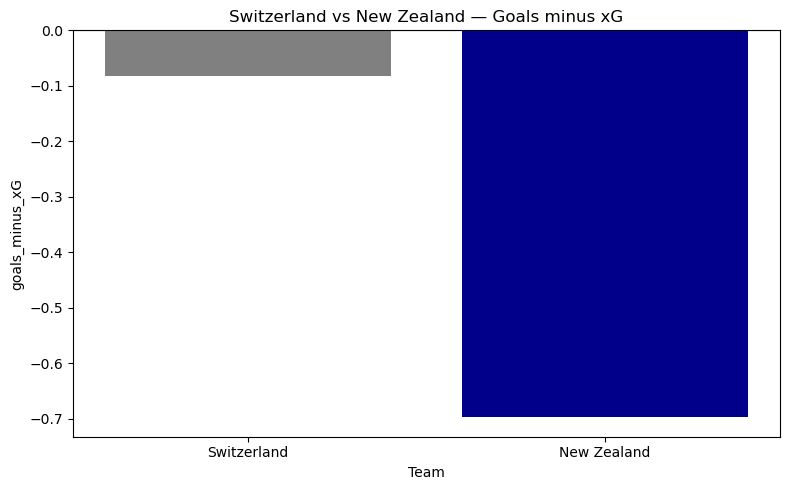

In [44]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
].copy()


teams = ["Switzerland", "New Zealand"]

goals_minus_xG = [
    match.loc[match["team"] == "Switzerland Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "New Zealand Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["gray", "darkblue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Switzerland vs New Zealand — Goals minus xG")

plt.tight_layout()
plt.show()

In [45]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
].copy()

In [46]:
match[["match_date", "team", "opponent"]]

,match_date,team,opponent
60,2023-07-30,New Zealand Women's,Switzerland Women's
61,2023-07-30,Switzerland Women's,New Zealand Women's


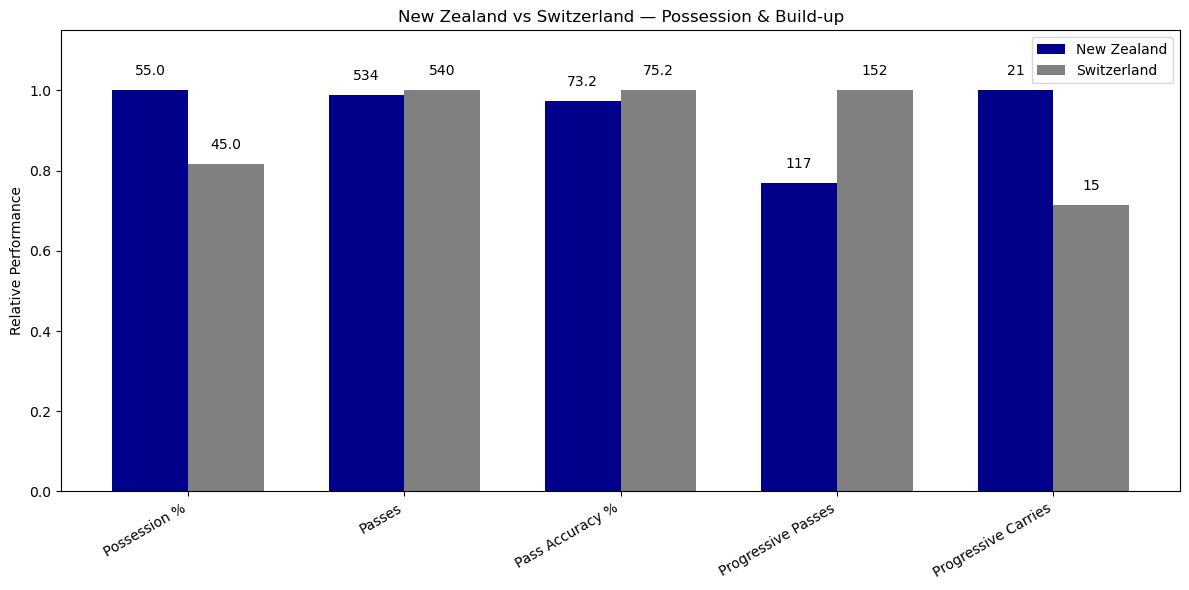

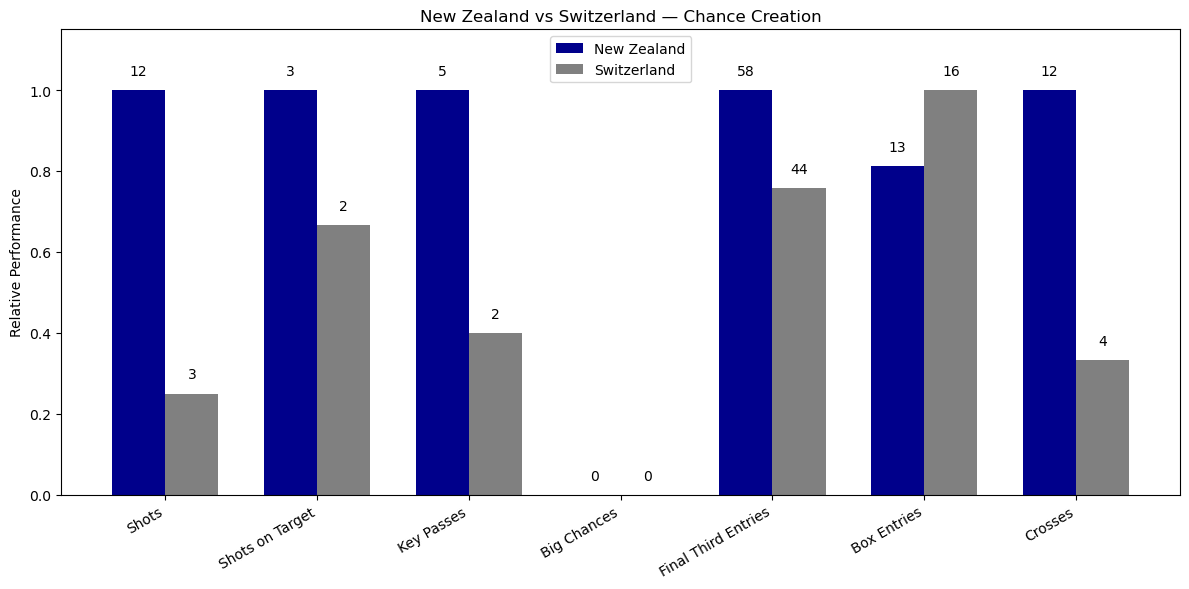

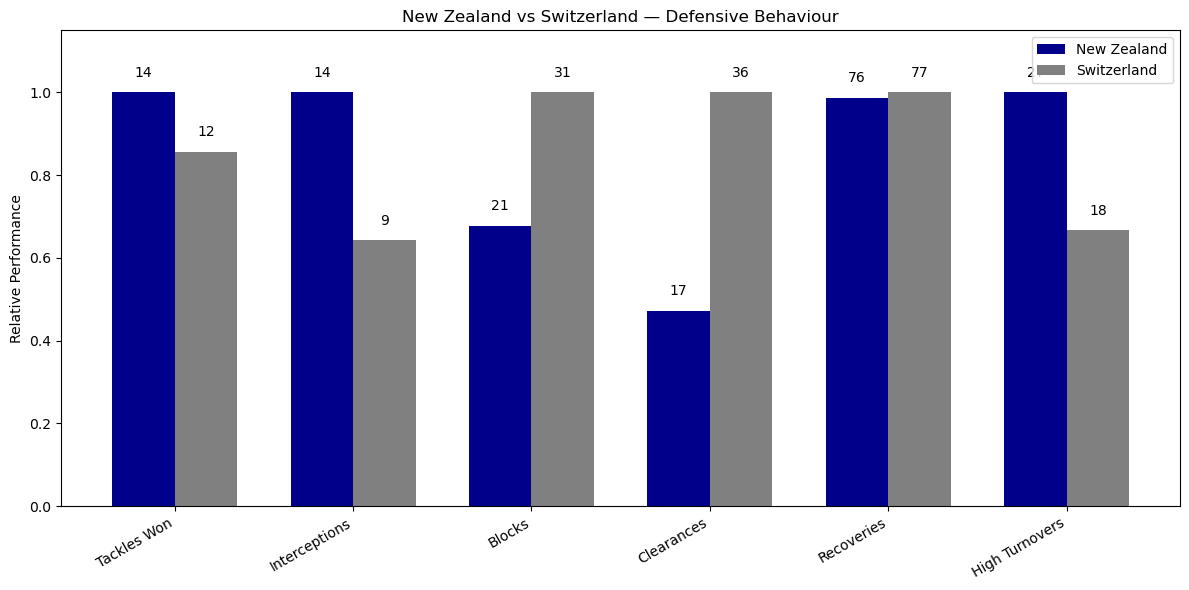

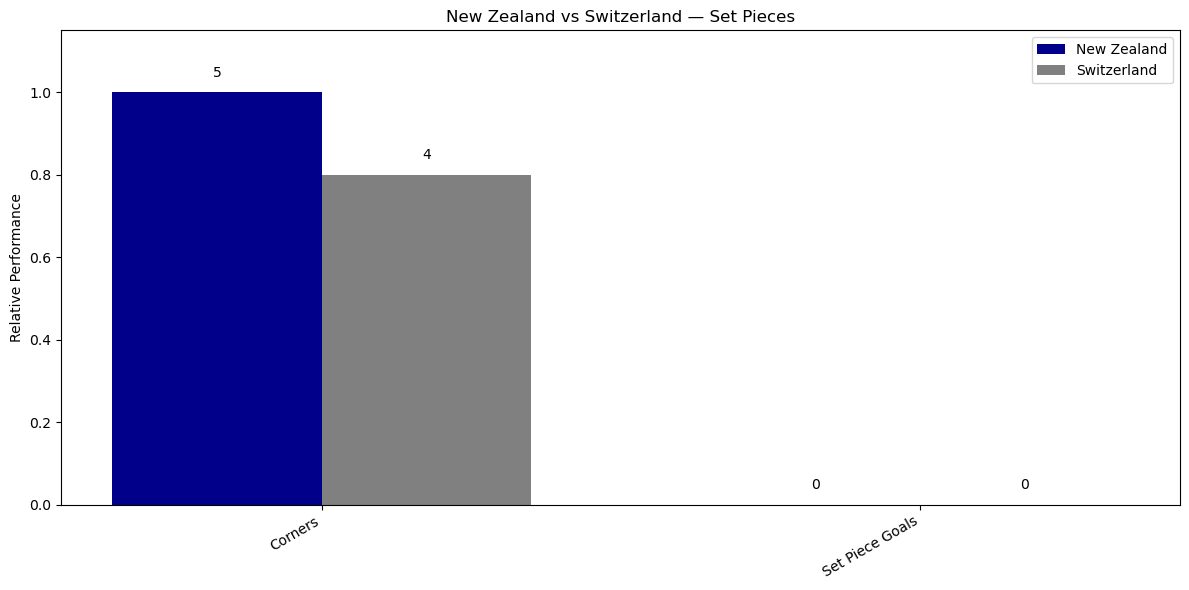

In [47]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "New Zealand Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "New Zealand Women's")
    )
].copy()
# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "New Zealand": "New Zealand Women's",
    "Switzerland": "Switzerland Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    nz_values = np.array([
        match.loc[
            match["team"] == team_names["New Zealand"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    swi_values = np.array([
         match.loc[
            match["team"] == team_names["Switzerland"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(nz_values, swi_values)

    # Normalize
    nz_normalized = np.divide(
        nz_values,
        max_values,
        out=np.zeros_like(nz_values),
        where=max_values != 0
    )

    swi_normalized = np.divide(
        swi_values,
        max_values,
        out=np.zeros_like(swi_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_nz = plt.bar(
        x - width / 2,
        nz_normalized,
        width,
        label="New Zealand",
        color="darkblue"
    )

    bars_swi = plt.bar(
        x + width / 2,
        swi_normalized,
        width,
        label="Switzerland",
        color="gray"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_nz, nz_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_swi, swi_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"New Zealand vs Switzerland — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of NZ-SWI Match

The game was very evenly matched. New Zealand maintained its aggressive, attacking style, forcing Switzerland to defend a lot. 
However, the European team managed to counterattack quite well and keep pace with New Zealand. <br>
<br>
When analyzing this game, I can see that the main problem for the team in black is their finishing.<br>
<br>
If we look at the statistics, New Zealand had:<br>
<br>
- **12** shots, but only **3** on goal. This suggests that 9 shots were either offside or saved. <br>
In the comparison table, we can see that Switzerland saved **2** shots, so the remaining **7** were offside, and **one** possibly hit the crossbar. <br>
<br>

Now, if we look at Switzerland’s statistics, we can see that, despite having fewer shots and being less offensive than New Zealand, they were more effective. <br>
<br>
- They had more progressive passes than the opposing team — **152 to 117** — and, in turn, the red team had a higher pass accuracy — **73.2% to 75.2%**. 
- They had only **3** shots, and **two** of them were on target, which counted as saves by the goalkeeper. 
<br>
The game ended in a tie, but the truth is that Switzerland was more effective and consistent than New Zealand.

# Analysis of Norways's Group Stage games

In [51]:
team = "Norway Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
0,3893787,New Zealand Women's,Norway Women's,Group
1,3893787,Norway Women's,New Zealand Women's,Group
34,3893804,Norway Women's,Switzerland Women's,Group
35,3893804,Switzerland Women's,Norway Women's,Group
66,3893820,Norway Women's,Philippines Women's,Group
67,3893820,Philippines Women's,Norway Women's,Group


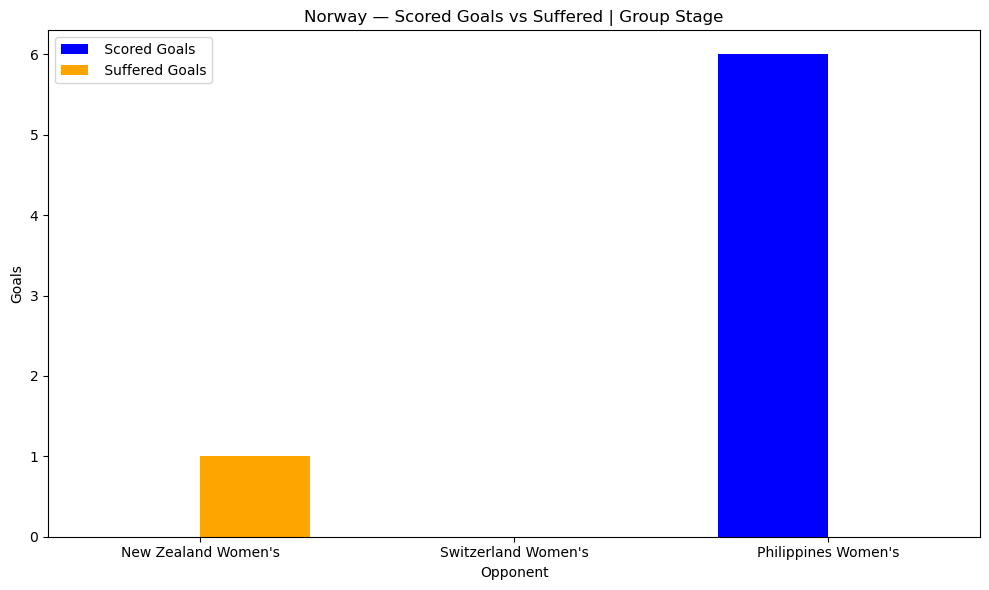

In [52]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Norway Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Suffered Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Norway — Scored Goals vs Suffered | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Norway played three games in the Group Stage of the World Cup. In these games, they conceded a Goal to New Zealand and scored 6 goals against the Philippines. Switzerland did not score any goals or concede any, meaning they tied the game.

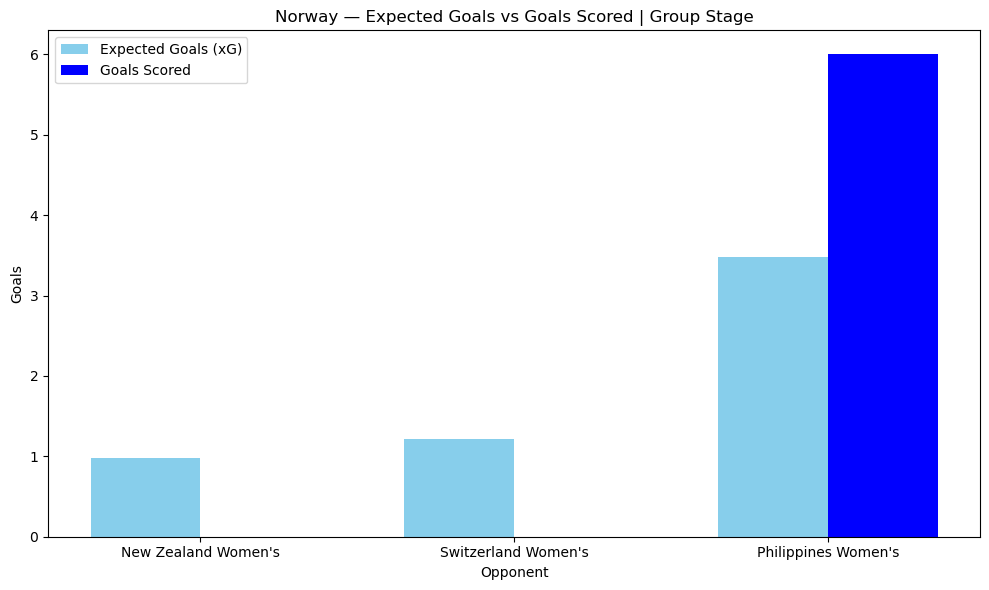

In [54]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Norway Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Norway — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

# Analysis of NOR - PHI

In [56]:
# Select the New Zealand vs Norway match

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "The Philippines": [
        match.loc[
            match["team"] == "Philippines Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Norway": [
        match.loc[
            match["team"] == "Norway Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["The Philippines", "Norway"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["The Philippines", "Norway"]
].round(1)


# Display table

comparison

,Metric,The Philippines,Norway
0,Goals,0.0,6.0
1,xG,0.1,3.5
2,Goals Minus xG,-0.1,1.5
3,Shots,4.0,31.0
4,Shots on Target,1.0,12.0
5,Saves,7.0,2.0
6,Possession %,30.4,69.6
7,Pass Accuracy %,56.8,83.2
8,Progressive Passes,86.0,161.0
9,Progressive Carries,10.0,23.0


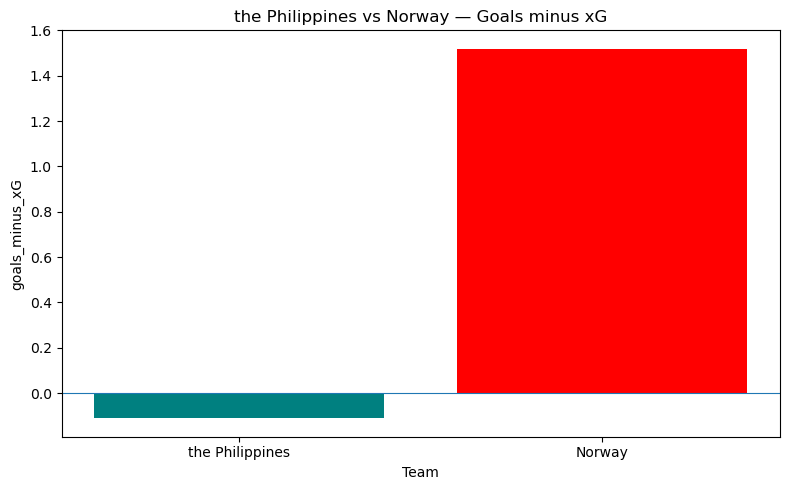

In [57]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    )
].copy()


teams = ["the Philippines", "Norway"]

goals_minus_xG = [
    match.loc[match["team"] == "Philippines Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Norway Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["teal", "red"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("the Philippines vs Norway — Goals minus xG")

plt.tight_layout()
plt.show()

In this match, there was a big discrepancy: the Philippines were bellow the expeted goals (at least one scored goal was projected) and Norway, had much more goals than foreseen (4 goals).

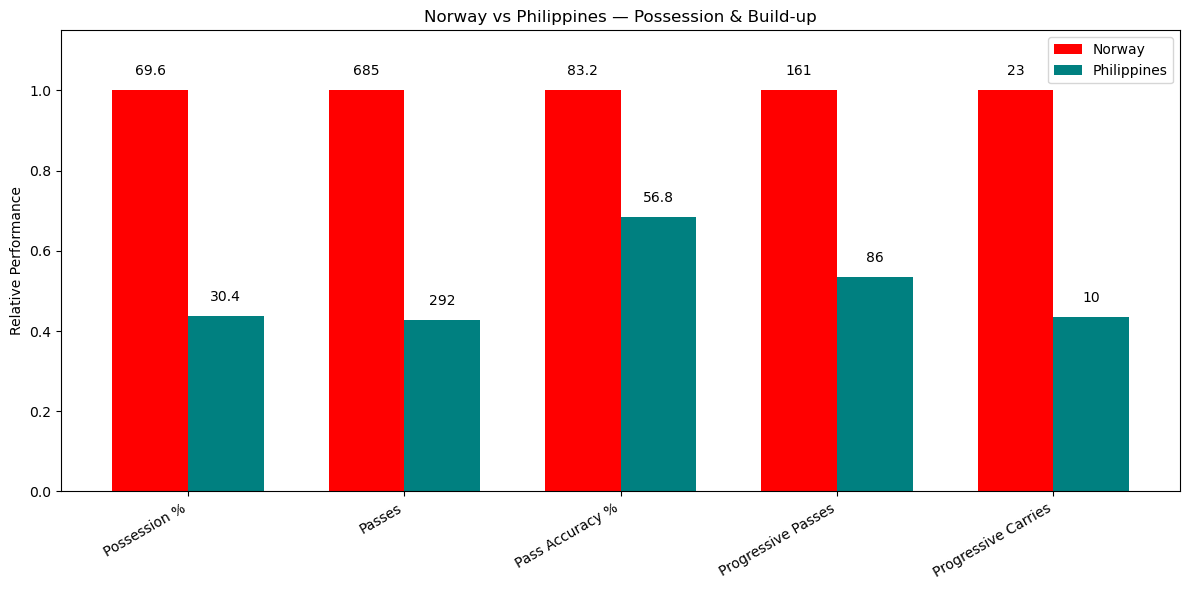

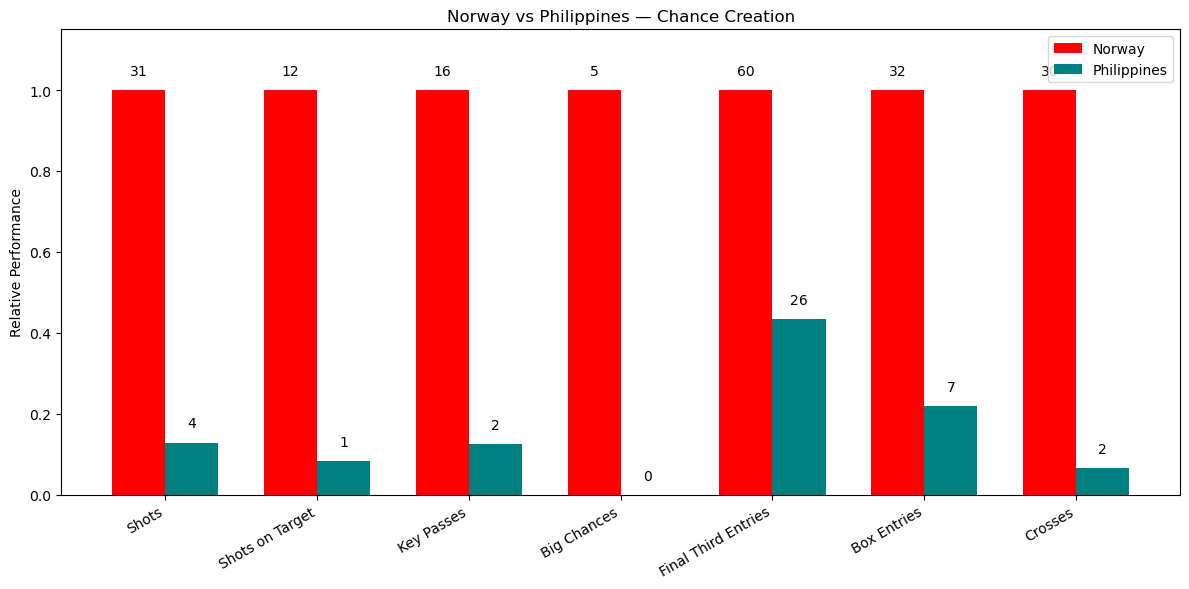

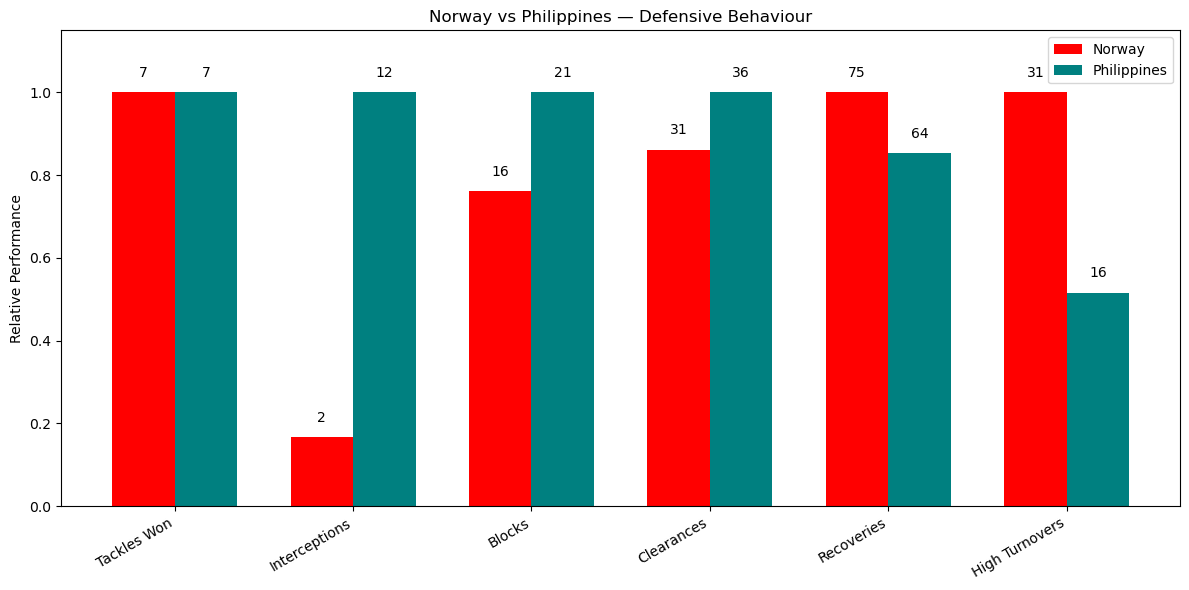

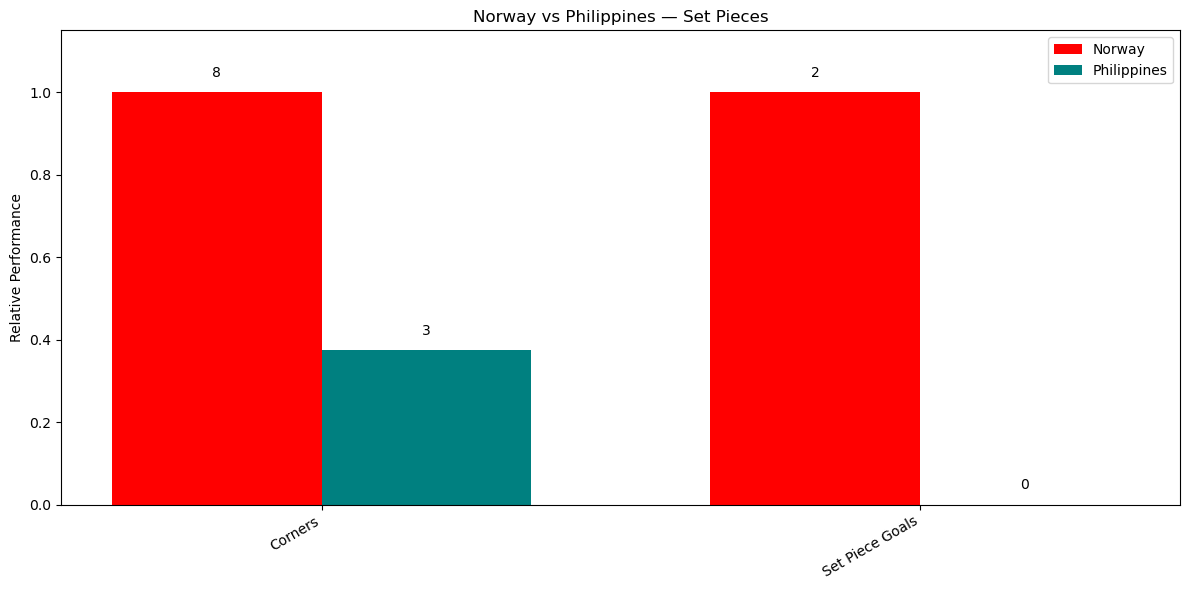

In [59]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Norway": "Norway Women's",
    "Philippines": "Philippines Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    norway_values = np.array([
        match.loc[
            match["team"] == team_names["Norway"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    philippines_values = np.array([
        match.loc[
            match["team"] == team_names["Philippines"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(norway_values, philippines_values)

    # Normalize
    norway_normalized = np.divide(
        norway_values,
        max_values,
        out=np.zeros_like(norway_values),
        where=max_values != 0
    )

    philippines_normalized = np.divide(
        philippines_values,
        max_values,
        out=np.zeros_like(philippines_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_norway = plt.bar(
        x - width / 2,
        norway_normalized,
        width,
        label="Norway",
        color="red"
    )

    bars_philippines = plt.bar(
        x + width / 2,
        philippines_normalized,
        width,
        label="Philippines",
        color="teal"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_norway, norway_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_philippines, philippines_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Norway vs Philippines — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of NOR-PHI 

Norway dominated the game against the Philippines, and this is clearly evident from the charts. <br>
<br>
Norway stands out most in the *possession and build-up*, and *chances created* charts, with an attacking style of play. 

- ball possession %: 69.6% - 30.4%
- pass accuracy %: 83.2% - 56.2%
- progressive carries %: 161 - 86
- key passes: 16 - 1

The defensive behavior chart shows a more aggressive defense by the Philippines; however, the Northern European team was not (far) behind. 

- Interceptions: 2–12
- Blocks: 16–21 
- Clearances: 36–31

In this match, Norway outplayed the Philippines in a concrete and structured manner.

# Analysis of NOR - SWI

In [63]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Switzerland": [
        match.loc[
            match["team"] == "Switzerland Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Norway": [
        match.loc[
            match["team"] == "Norway Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Switzerland", "Norway"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Switzerland", "Norway"]
].round(1)


# Display table

comparison

,Metric,Switzerland,Norway
0,Goals,0.0,0.0
1,xG,0.9,1.2
2,Goals Minus xG,-0.9,-1.2
3,Shots,8.0,15.0
4,Shots on Target,1.0,5.0
5,Saves,5.0,1.0
6,Possession %,43.3,56.7
7,Pass Accuracy %,79.2,78.7
8,Progressive Passes,126.0,119.0
9,Progressive Carries,21.0,21.0


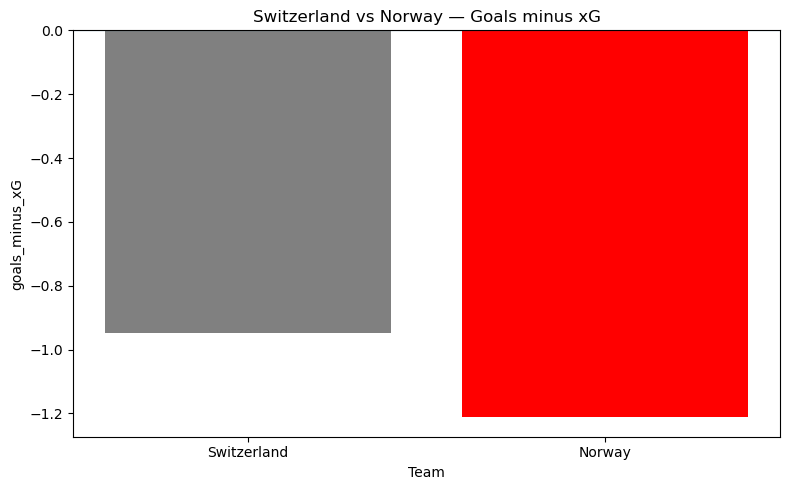

In [64]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    )
].copy()


teams = ["Switzerland", "Norway"]

goals_minus_xG = [
    match.loc[match["team"] == "Switzerland Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Norway Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["gray", "red"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Switzerland vs Norway — Goals minus xG")

plt.tight_layout()
plt.show()

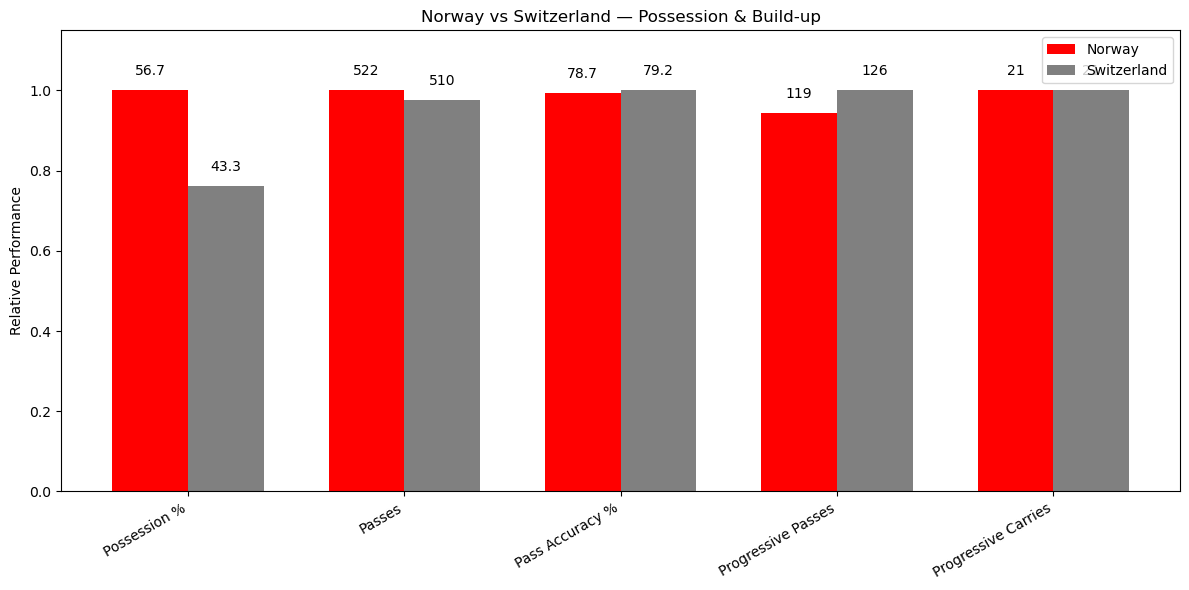

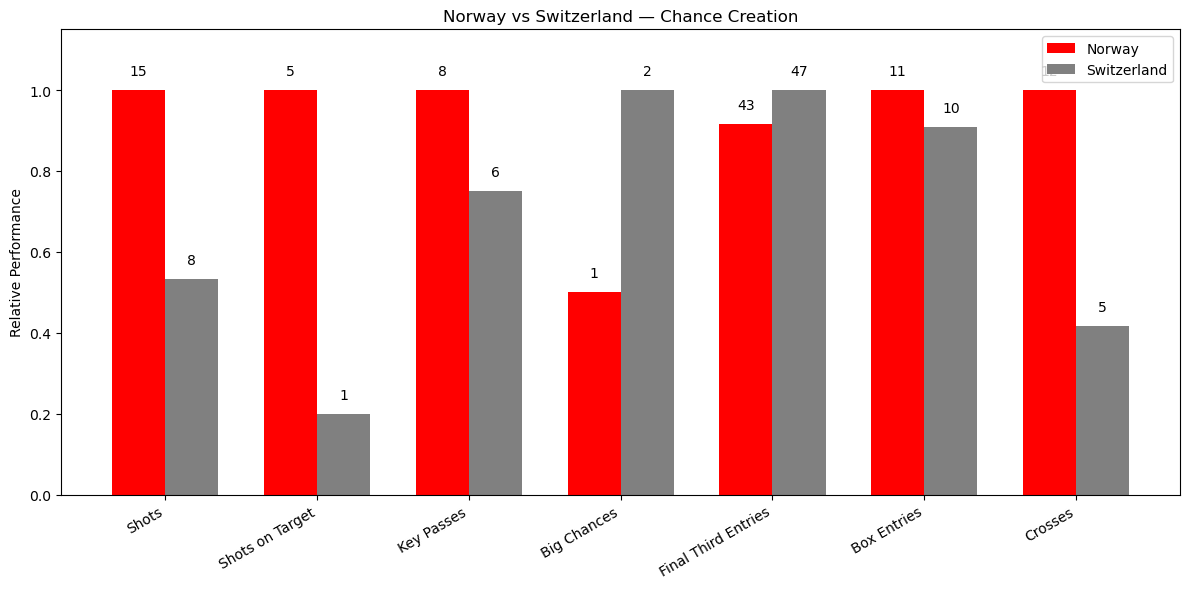

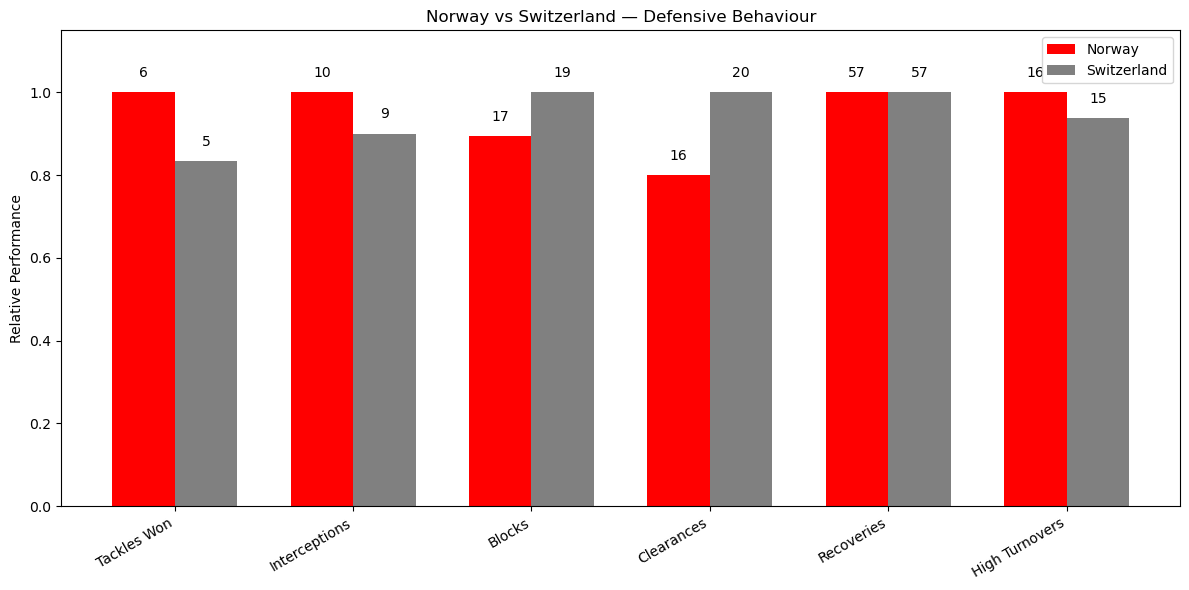

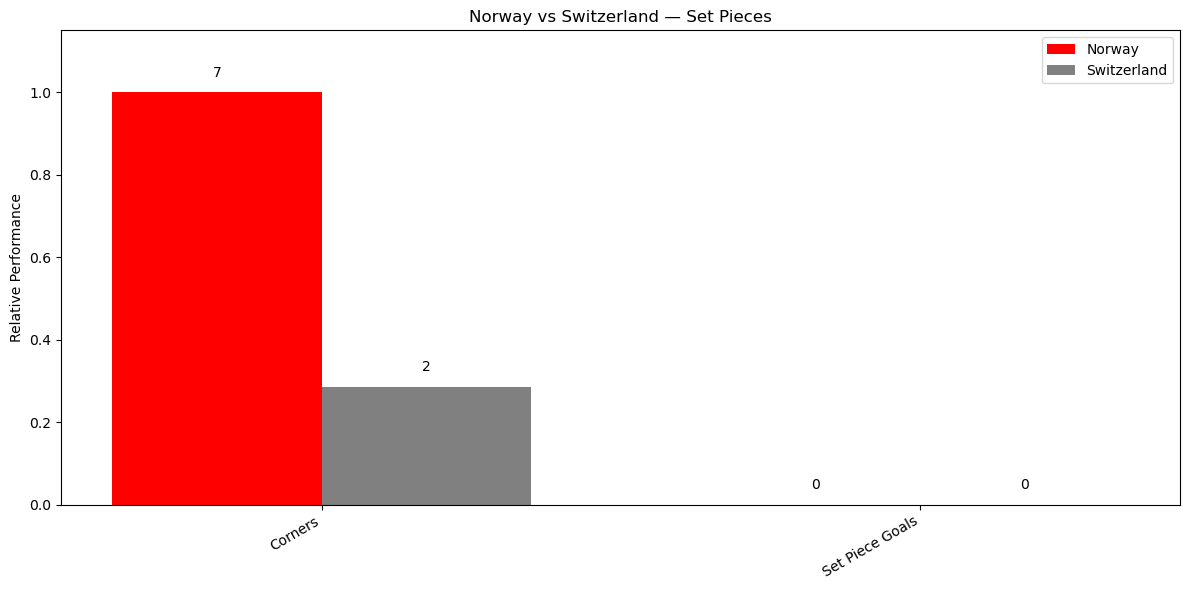

In [65]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Norway": "Norway Women's",
    "Switzerland": "Switzerland Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    norway_values = np.array([
        match.loc[
            match["team"] == team_names["Norway"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    swi_values = np.array([
        match.loc[
            match["team"] == team_names["Switzerland"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(norway_values, swi_values)

    # Normalize
    norway_normalized = np.divide(
        norway_values,
        max_values,
        out=np.zeros_like(norway_values),
        where=max_values != 0
    )

    swi_normalized = np.divide(
        swi_values,
        max_values,
        out=np.zeros_like(swi_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_norway = plt.bar(
        x - width / 2,
        norway_normalized,
        width,
        label="Norway",
        color="red"
    )

    bars_swi = plt.bar(
        x + width / 2,
        swi_normalized,
        width,
        label="Switzerland",
        color="gray"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_norway, norway_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_swi, swi_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Norway vs Switzerland — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of NOR-SWI 

In the games analyzed, Switzerland appears to have a **style of play that adapts to its opponent**. It’s no coincidence that, against teams with very aggressive styles like New Zealand and Norway, they managed to draw and even posted some very similar statistics, such as: <br>
<br>
- pass accuracy %: 78.7% - 79.2%
- progressive passes: 119 - 126
- progressive carries: 21 - 21
<br>
However, Norway is a team that truly plays an attacking style, as demonstrated by these figures:<br>
<br>
- shots: 15–8 
- shots on target: 5–1
- key passes: 8–6 
<br>

From this match, we can conclude that Norway was more **productive** than Switzerland, but that does not necessarily mean it was more **efficient**, since neither team ended up scoring any goals.

# Analysis Philippines Group Stage games

In [68]:
team = "Philippines Women's"

games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == team) |
    (womens_world_cup_stats["opponent"] == team)
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
4,3893789,Philippines Women's,Switzerland Women's,Group
5,3893789,Switzerland Women's,Philippines Women's,Group
32,3893803,New Zealand Women's,Philippines Women's,Group
33,3893803,Philippines Women's,New Zealand Women's,Group
66,3893820,Norway Women's,Philippines Women's,Group
67,3893820,Philippines Women's,Norway Women's,Group


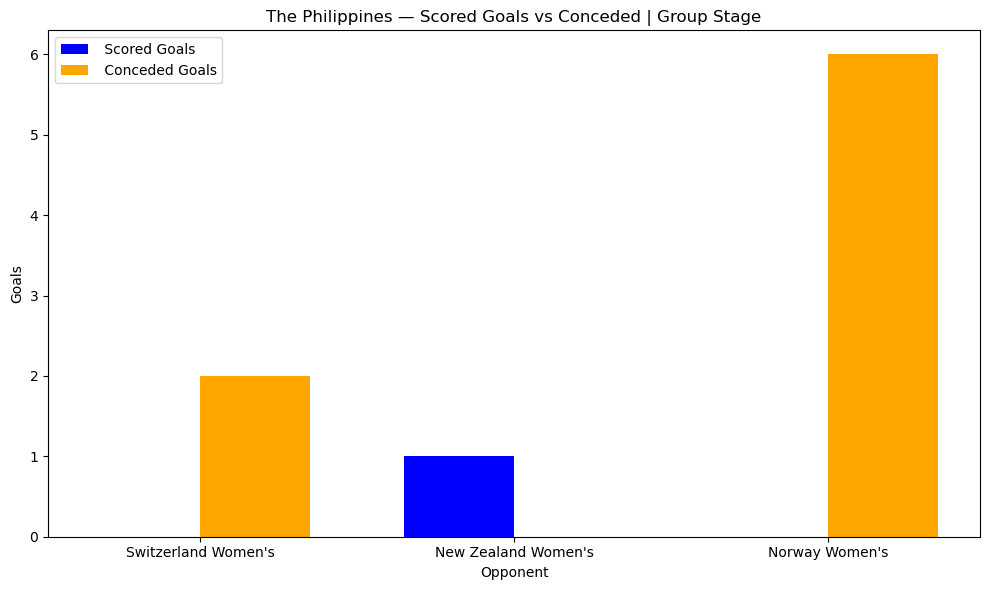

In [69]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Philippines Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("The Philippines — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

The Philippines conceded 8 goals at total (2 to Switzerland and 6 to Norway), and scored 1 goal against New Zealand.

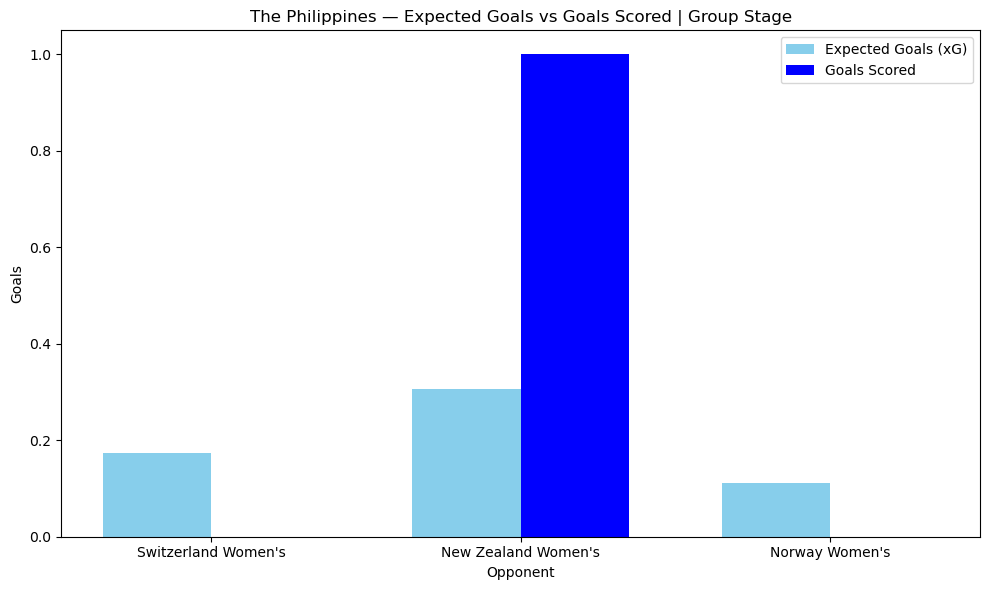

In [71]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Philippines Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("The Philippines — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

# Analysis of PHI-SWI

In [74]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    )
].copy()

# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "The Philippines": [
        match.loc[
            match["team"] == "Philippines Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Switzerland": [
        match.loc[
            match["team"] == "Switzerland Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["The Philippines", "Switzerland"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["The Philippines", "Switzerland"]
].round(1)


# Display table

comparison

,Metric,The Philippines,Switzerland
0,Corners,0,3
1,Set Piece Goals,0,0


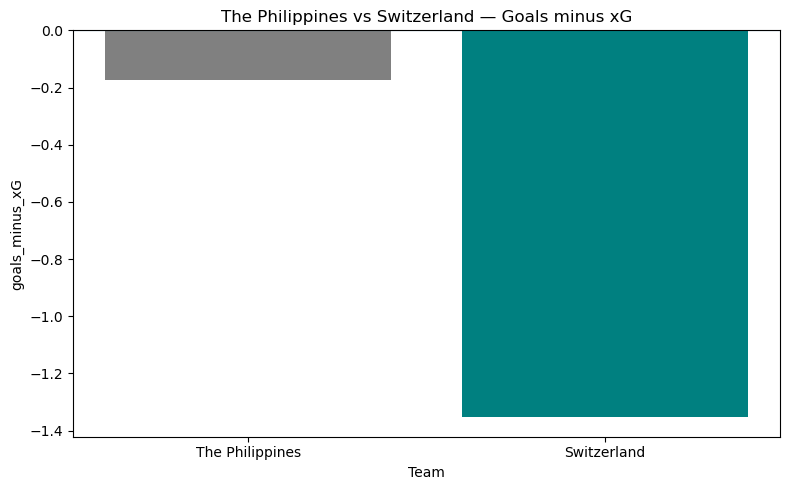

In [76]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    )
].copy()


teams = ["The Philippines", "Switzerland"]

goals_minus_xG = [
    match.loc[match["team"] == "Philippines Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Switzerland Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["gray", "teal"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("The Philippines vs Switzerland — Goals minus xG")

plt.tight_layout()
plt.show()

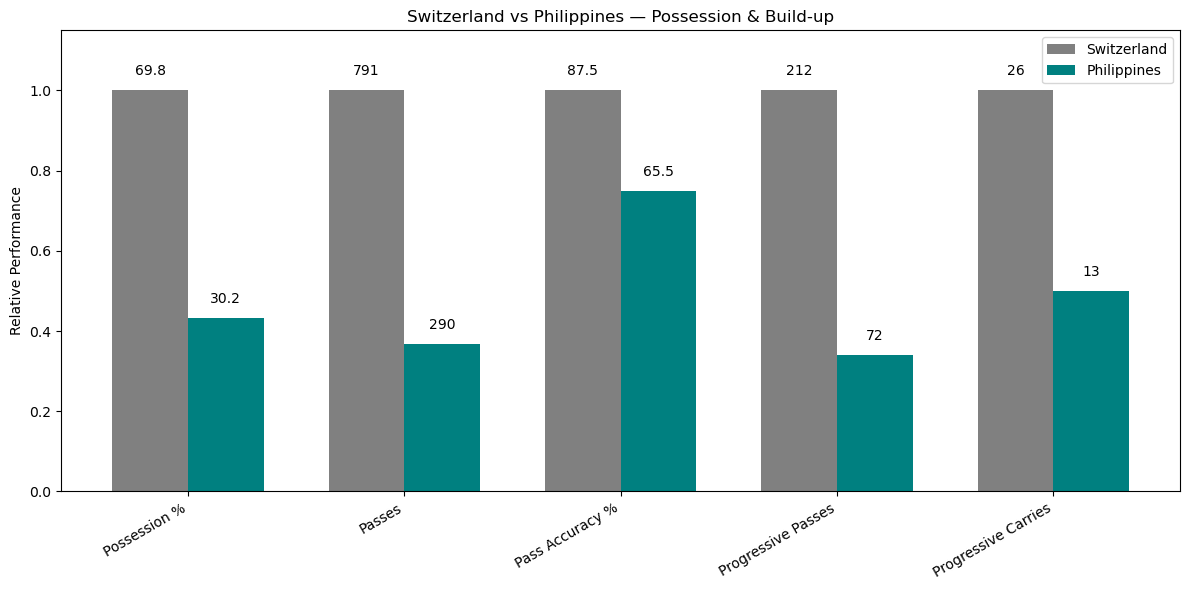

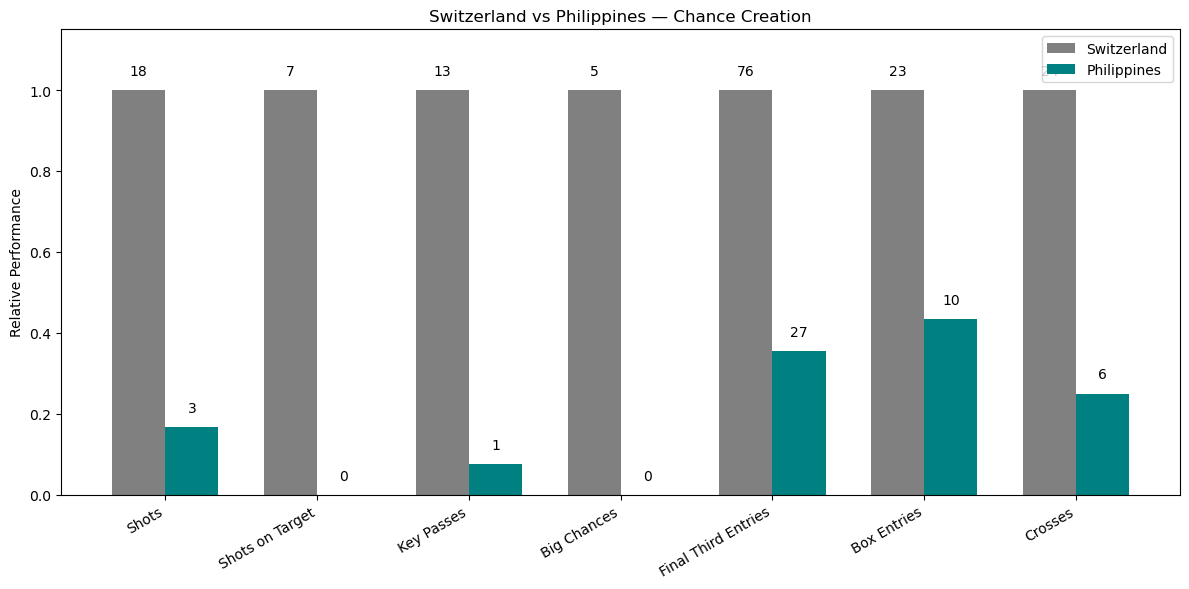

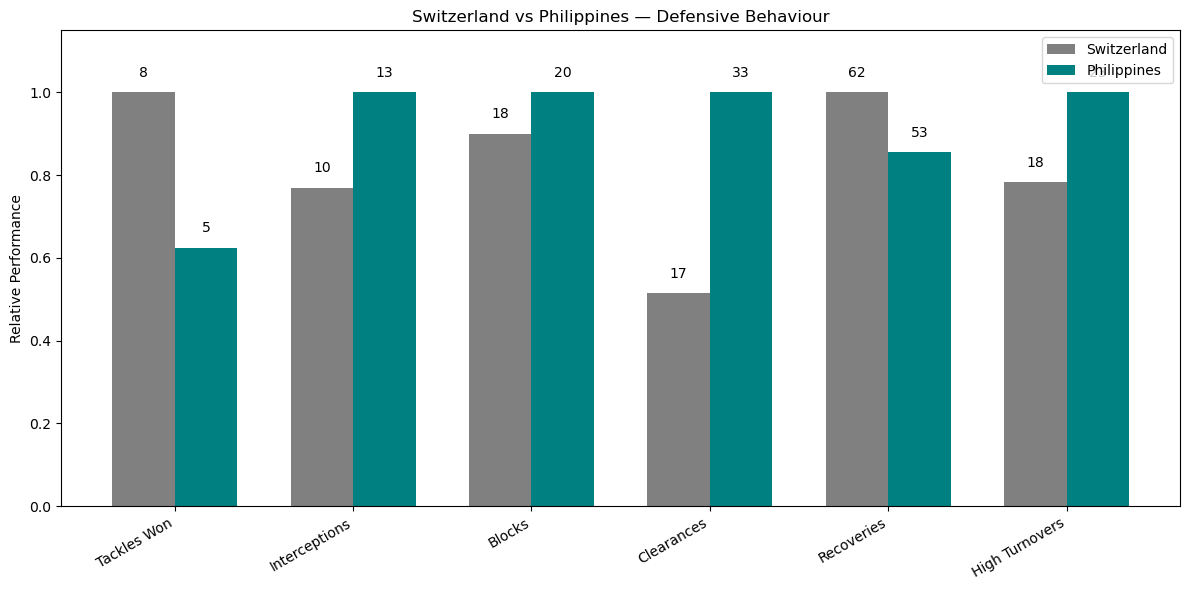

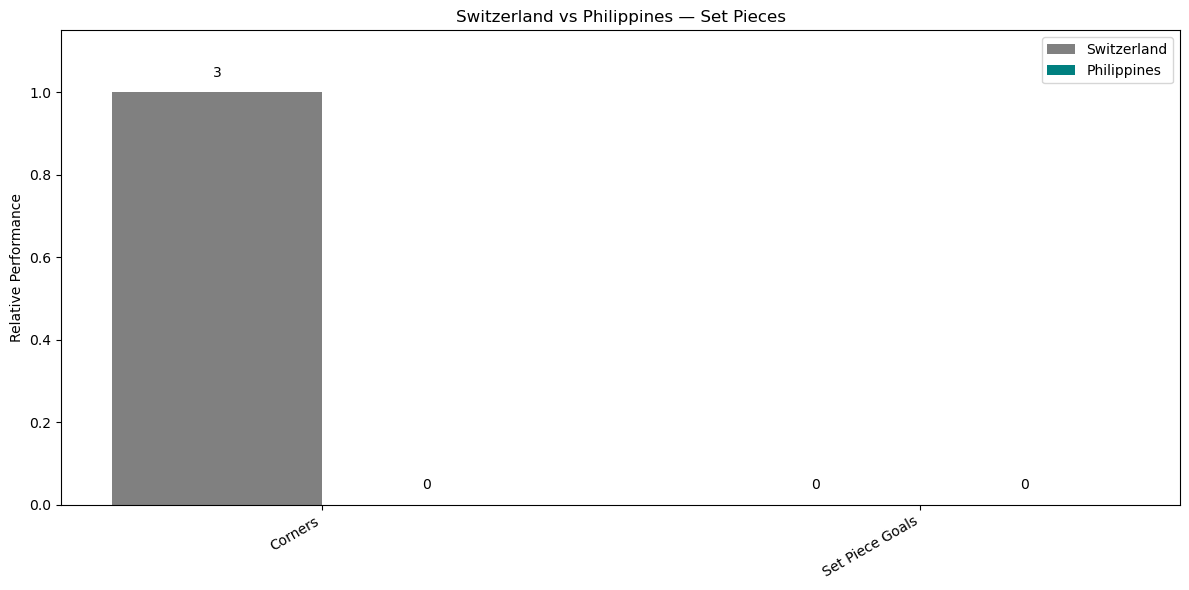

In [80]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Philippines Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "Philippines Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Switzerland": "Switzerland Women's",
    "Philippines": "Philippines Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    swi_values = np.array([
        match.loc[
            match["team"] == team_names["Switzerland"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    philippines_values = np.array([
        match.loc[
            match["team"] == team_names["Philippines"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(swi_values, philippines_values)

    # Normalize
    swi_normalized = np.divide(
        swi_values,
        max_values,
        out=np.zeros_like(swi_values),
        where=max_values != 0
    )

    philippines_normalized = np.divide(
        philippines_values,
        max_values,
        out=np.zeros_like(philippines_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_swi = plt.bar(
        x - width / 2,
        swi_normalized,
        width,
        label="Switzerland",
        color="gray"
    )

    bars_philippines = plt.bar(
        x + width / 2,
        philippines_normalized,
        width,
        label="Philippines",
        color="teal"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_swi, swi_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_philippines, philippines_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Switzerland vs Philippines — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of SWI-PHI 

The Philippines were defeated by Switzerland, as shown in the charts. Although they maintained a very defensive stance throughout the game, they were unable to break through and capitalize on the red team’s attack.
Switzerland, on the other hand, which has consistently adapted its style of play to each opponent, felt that it could play more offensively in this match, proving highly productive and achieving overwhelming results. 

# Analysis Switzerland Group Stage games

In [98]:
team = "Switzerland Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
4,3893789,Philippines Women's,Switzerland Women's,Group
5,3893789,Switzerland Women's,Philippines Women's,Group
34,3893804,Norway Women's,Switzerland Women's,Group
35,3893804,Switzerland Women's,Norway Women's,Group
60,3893817,New Zealand Women's,Switzerland Women's,Group
61,3893817,Switzerland Women's,New Zealand Women's,Group


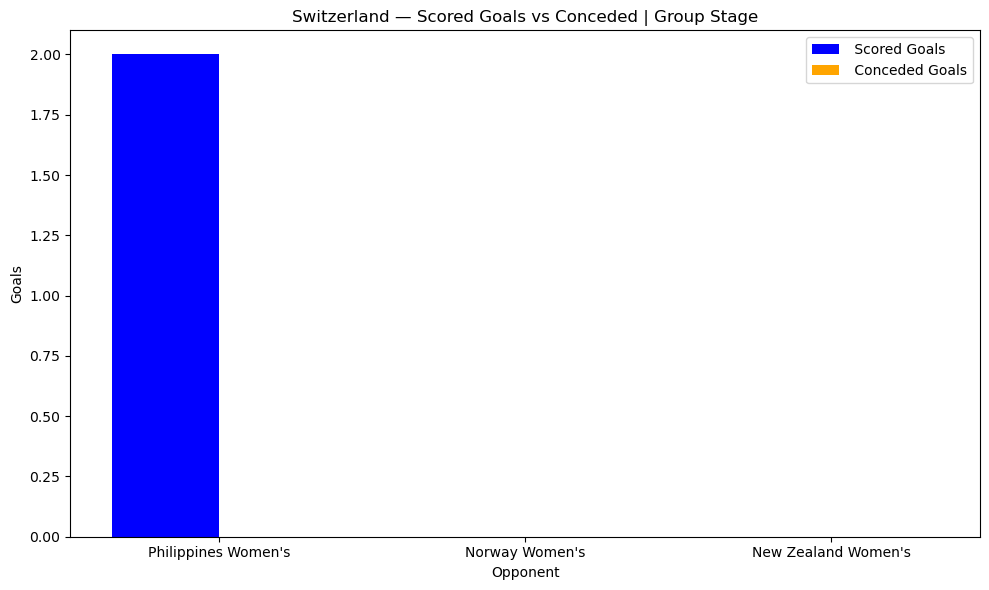

In [100]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Switzerland Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Switzerland — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

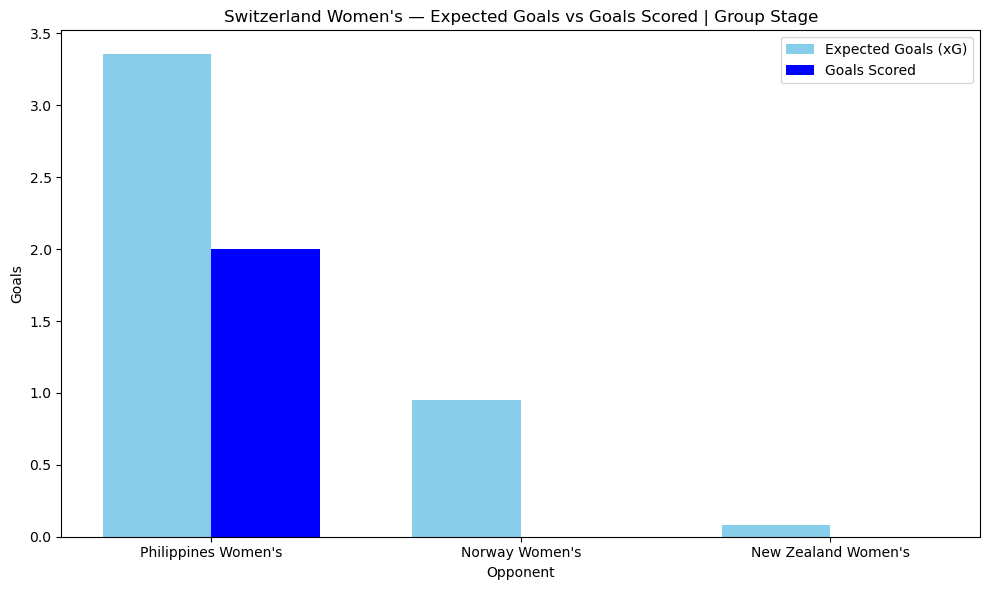

In [102]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Switzerland Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Switzerland Women's — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

# Final Conclusion

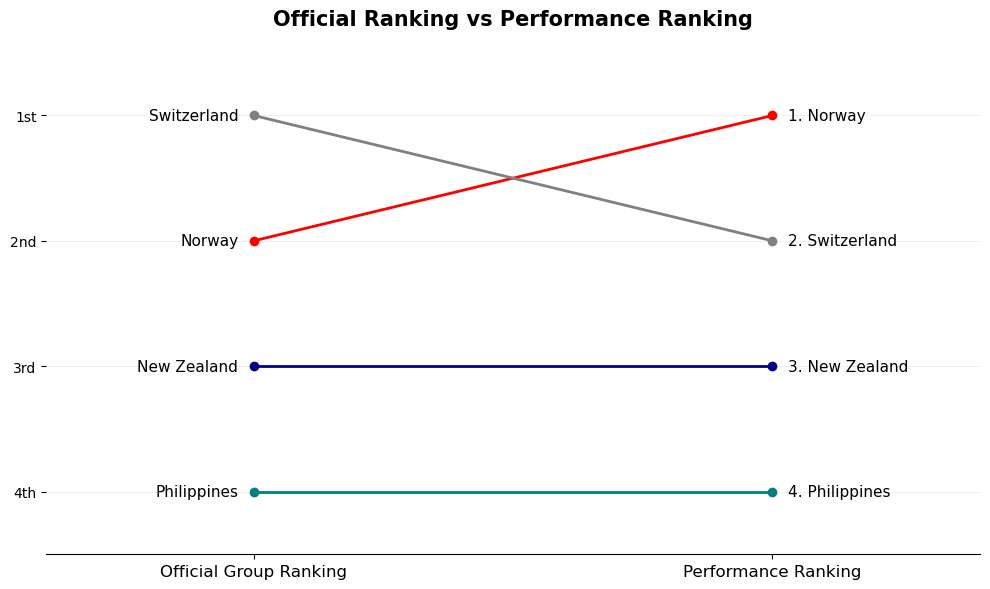

In [107]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DATA
# ==========================================

ranking = pd.DataFrame({
    "team": ["Norway", "Switzerland", "New Zealand", "Philippines"],
    "official_rank": [2, 1, 3, 4],
    "performance_rank": [1, 2, 3, 4]
})

# ==========================================
# COLORS
# ==========================================

team_colors = {
    "Norway": "red",
    "Switzerland": "gray",
    "New Zealand": "darkblue",
    "Philippines": "teal"
}

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in ranking.iterrows():

    ax.plot(
        [0, 1],
        [row["official_rank"], row["performance_rank"]],
        marker="o",
        linewidth=2,
        color=team_colors[row["team"]]
    )

    # Official ranking
    ax.text(
        -0.03,
        row["official_rank"],
        row["team"],
        ha="right",
        va="center",
        fontsize=11
    )

    # Performance ranking
    ax.text(
        1.03,
        row["performance_rank"],
        f'{row["performance_rank"]}. {row["team"]}',
        ha="left",
        va="center",
        fontsize=11
    )

# ==========================================
# FORMATTING
# ==========================================

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(4.5, 0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Official Group Ranking",
    "Performance Ranking"
], fontsize=12)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1st", "2nd", "3rd", "4th"])

ax.set_title(
    "Official Ranking vs Performance Ranking",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

Although Switzerland finished above Norway in the group, the performance analysis suggests that Norway demonstrated a stronger overall performance.
Switzerland, despite playing very evenly matched games and remaining undefeated, fell short of its xG in terms of goals scored.
Norway was a very consistent team that showed strong form in the games analyzed, despite losing one match. 